## Next Steps:

1- construir knife scores para silhouette

2 - interpretar ambos os knife scores e documentar 

3 - documentar a definição dos modelos 

In [4]:
import pandas as pd 
import numpy as np 
from sklearn.cluster import KMeans 
from sklearn.cluster import AffinityPropagation
import sklearn.metrics as mt
import sys 
sys.path.append('../../libs/src')
import data_utils 
from matplotlib import pyplot as plt 
import matplotlib.cm as cm


In [5]:
raw_dataset = pd.read_csv('../data/X_dataset.csv')
raw_dataset

,alcohol,malic_acid,ash,ash_alcanity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280,proline
0,1.518613,0.191700,0.232053,-1.169593,1.913905,0.627586,0.573840,-0.659563,1.224884,0.251717,0.455285,0.970696,0.561341
1,0.246290,0.205534,-0.827996,-2.490847,0.018145,0.575862,0.510549,-0.820719,-0.544721,-0.293321,0.463415,0.780220,0.550642
2,0.196879,0.320158,1.109334,-0.268738,0.088358,0.627586,0.611814,-0.498407,2.135968,0.269020,0.447154,0.695971,0.646933
3,1.691550,0.239130,0.487926,-0.809251,0.930918,0.989655,0.664557,-0.981875,1.032155,1.186068,0.308943,0.798535,0.857347
4,0.295700,0.365613,1.840403,0.451946,1.281985,0.627586,0.495781,0.226796,0.401404,-0.319276,0.455285,0.608059,0.325963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,0.970356,0.305159,0.301803,-0.332922,0.241379,0.056962,1.274310,-0.930179,1.142811,0.130081,0.172161,0.329529
174,0.493343,0.626482,0.414820,1.052516,0.158572,0.282759,0.086498,0.549108,-0.316950,0.969783,0.178862,0.106227,0.336662
175,0.332758,0.699605,-0.389355,0.151661,1.422412,0.210345,0.073840,0.549108,-0.422075,2.224236,0.089431,0.106227,0.397290
176,0.209232,0.365613,0.012732,0.151661,1.422412,0.231034,0.071730,1.354888,-0.229346,1.834923,0.097561,0.128205,0.400856


### 1.0 - Data Preparation

In [6]:
normalizer = data_utils.normalizer(df=raw_dataset,
                                   strategy = 'minMaxScaller')

dataset_normalized = normalizer.getDfcolumnNormalized(raw_dataset)
dataset_normalized

,alcohol,malic_acid,ash,ash_alcanity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280,proline
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856


## 2.0 -Treinamento e  Modelos de Clustering

### 2.1 - KMeans

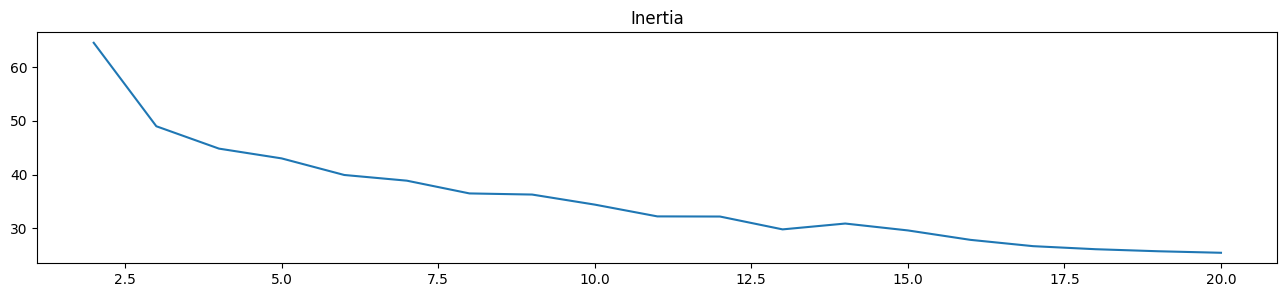

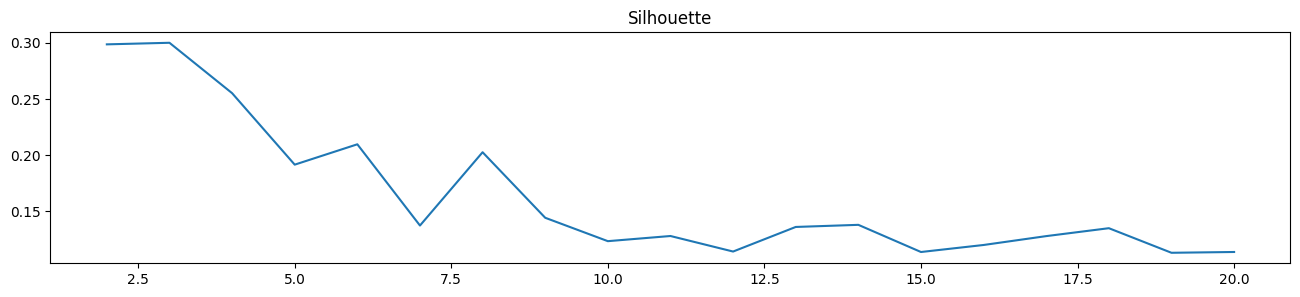

In [ ]:
k_values = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
kmeans_wcss_values = []
kmeans_silhouet_score_values = []
kmeans_predictions = []

for k in k_values:
    Kmeans_Model = KMeans(n_clusters=k)
    Kmeans_Model.fit(dataset_normalized)

    kmeans_wcss_values.append(Kmeans_Model.inertia_)
    kmeans_silhouet_score_values.append(mt.silhouette_score(dataset_normalized, Kmeans_Model.labels_))
    kmeans_predictions.append(Kmeans_Model.labels_)



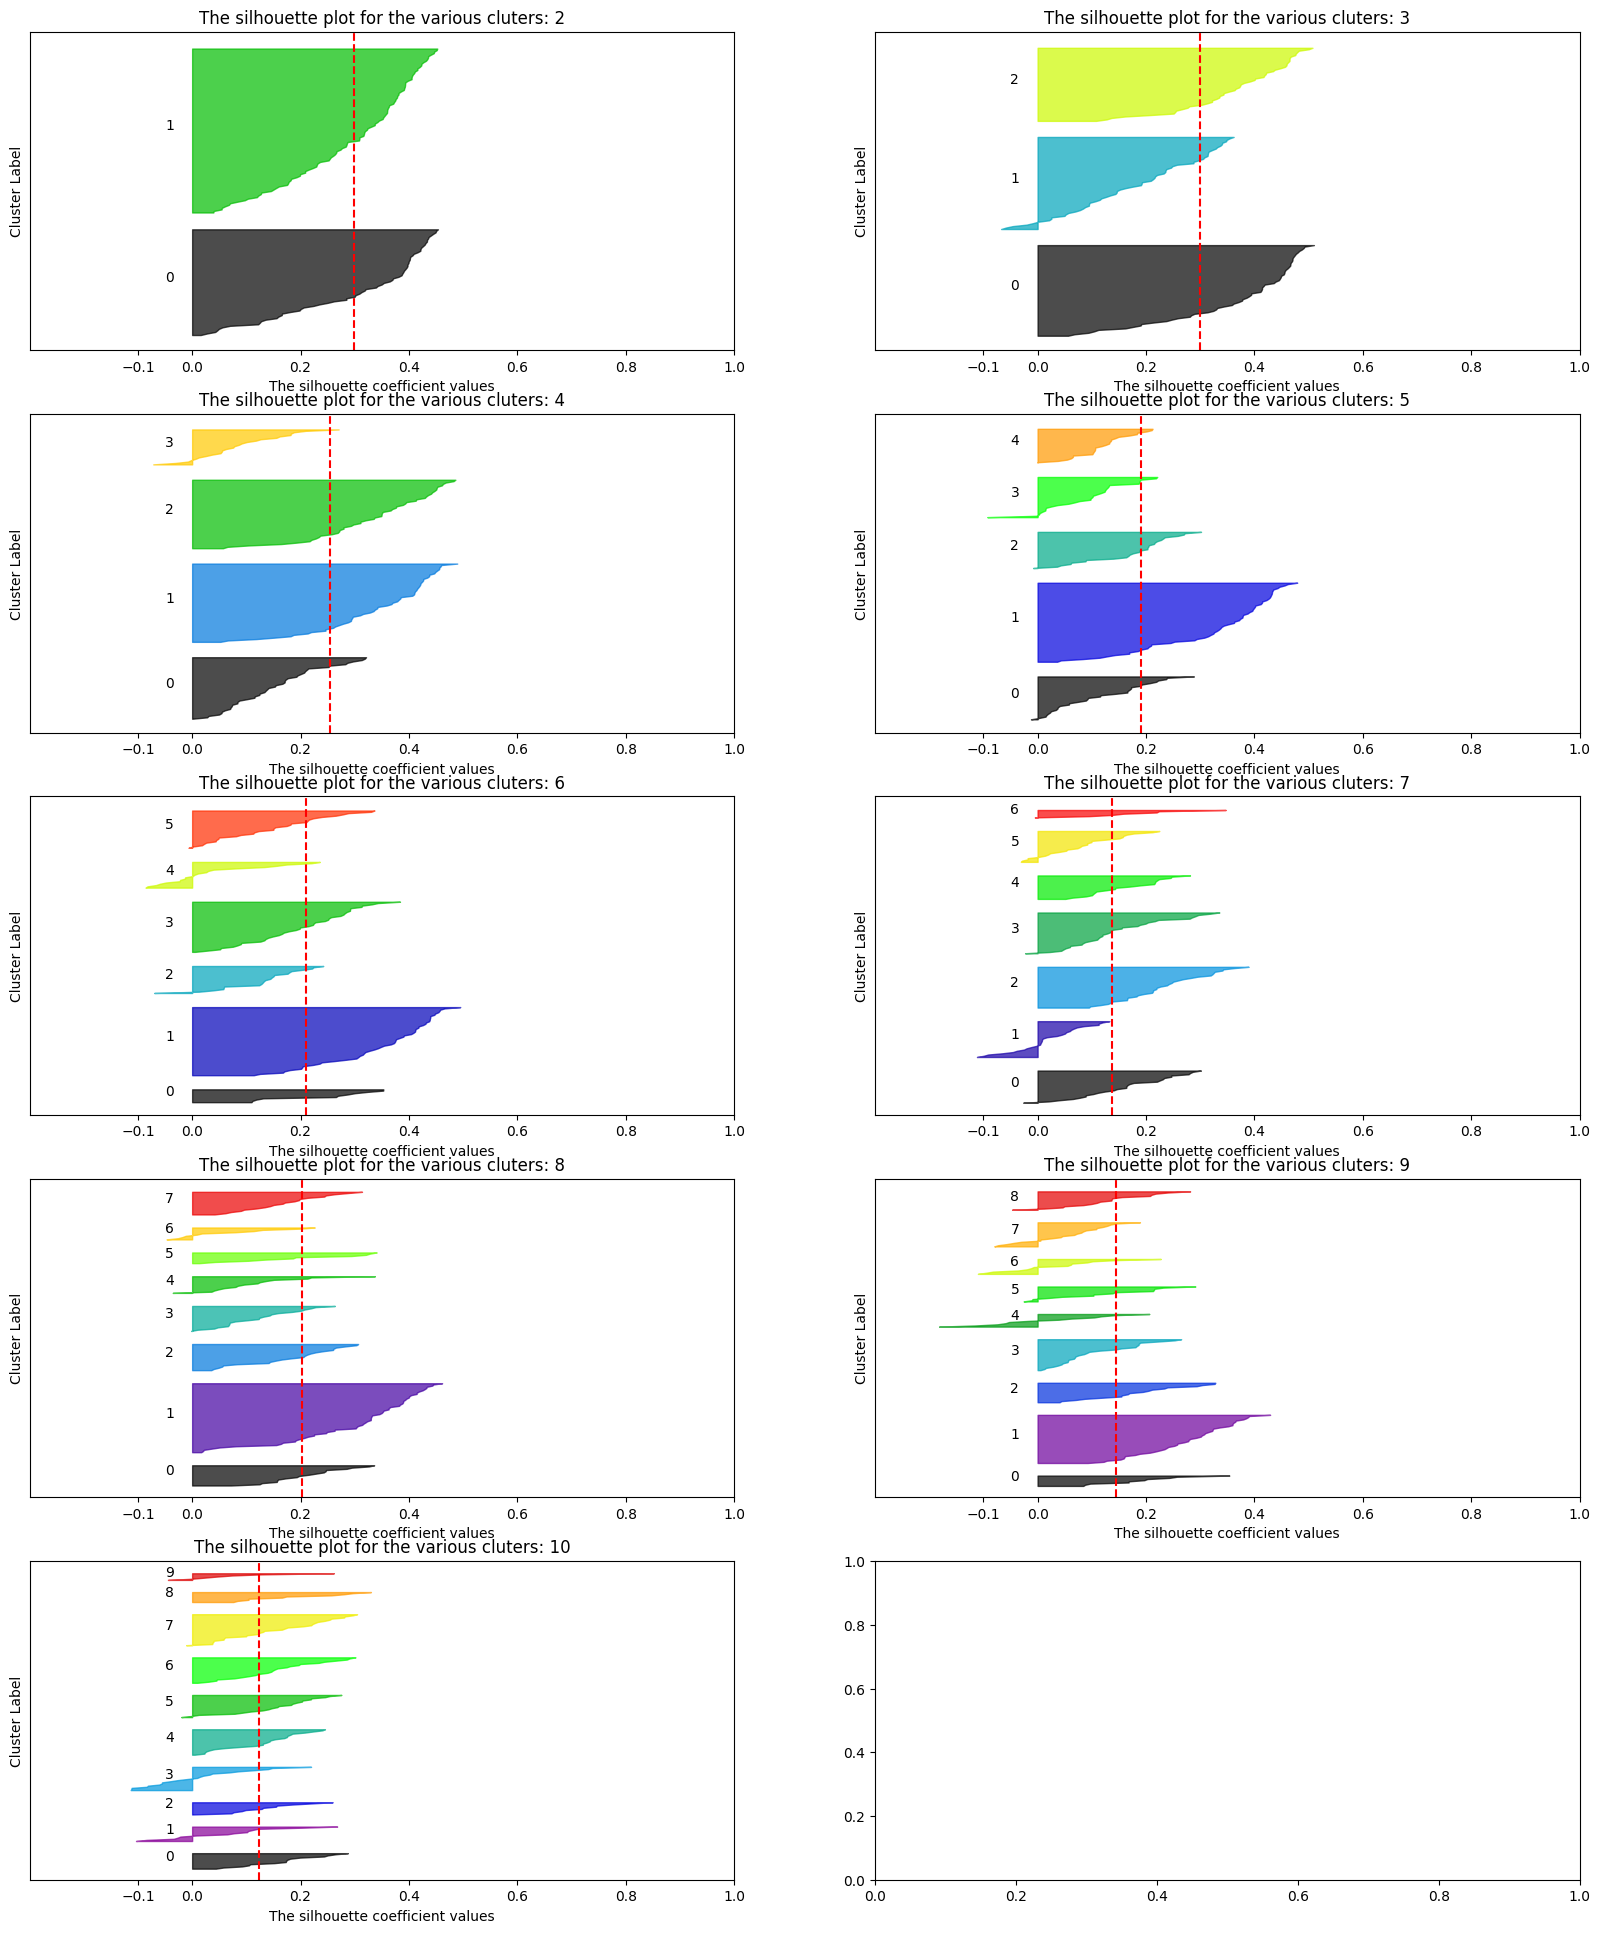

In [ ]:


def plot_knife_silhouete_values(n_clusters_values   : list,
                                 predictions        : list,
                                 silhouette_scores  : list,
                                 n_cols             : int = 2):
    
    n_rows = (len(n_clusters_values)//2) + 1 if len(n_clusters_values)%2 == 1 else len(n_clusters_values)/2   
    fig, ax = plt.subplots(int(n_rows), n_cols, figsize=(20,24))

    for idx, n_clusters in enumerate(n_clusters_values):
            
            current_axis = ax[idx//2,idx%2]
            current_axis.set_xlim([-0.3,1])
            current_axis.set_ylim([0, len(dataset_normalized) + (n_clusters + 1) * 10])

            
            samples = mt.silhouette_samples(dataset_normalized, predictions[idx])
        
            # ---------------------------------------------- #
            silhouette_avg = silhouette_scores[idx]
            # ---------------------------------------------- #

            y_lower = 10
            
            for i in range(int(n_clusters)):
                ith_cluster_silhouette_values = samples[predictions[idx] == i]
                ith_cluster_silhouette_values.sort()

                size_cluster_i = ith_cluster_silhouette_values.shape[0]
                y_upper = y_lower + size_cluster_i

                color = cm.nipy_spectral(float(i)/n_clusters)

                current_axis.fill_betweenx(
                    y = np.arange(y_lower, y_upper), 
                    x1= 0, 
                    x2 = ith_cluster_silhouette_values, 
                    facecolor=color, 
                    edgecolor=color, 
                    alpha = 0.7
                )

                current_axis.text(-0.05, y_lower + .5 * size_cluster_i, str(i))

                y_lower = y_upper + 10

                
                current_axis.set_title(f'The silhouette plot for the various cluters: {n_clusters_values[idx]}')

            
            current_axis.set_xlabel("The silhouette coefficient values")
            current_axis.set_ylabel("Cluster Label")

            current_axis.axvline(x=silhouette_avg, color="red", linestyle='--')

            current_axis.set_yticks([])
            current_axis.set_xticks([-0.1,0,.2,.4,.6,.8,1])


    plt.show()    




### 2.2 - Affinity Propagation 

Text(0.5, 1.0, 'Silhouete score por preference')

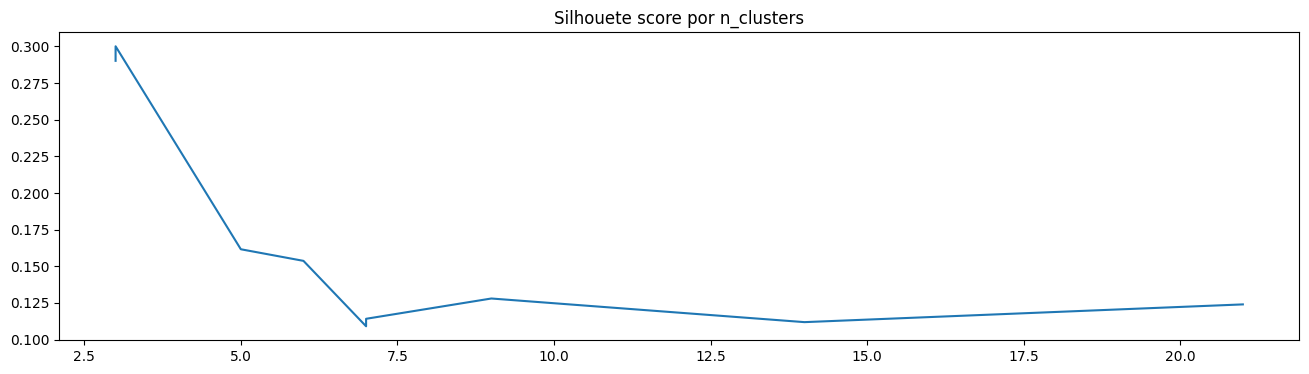

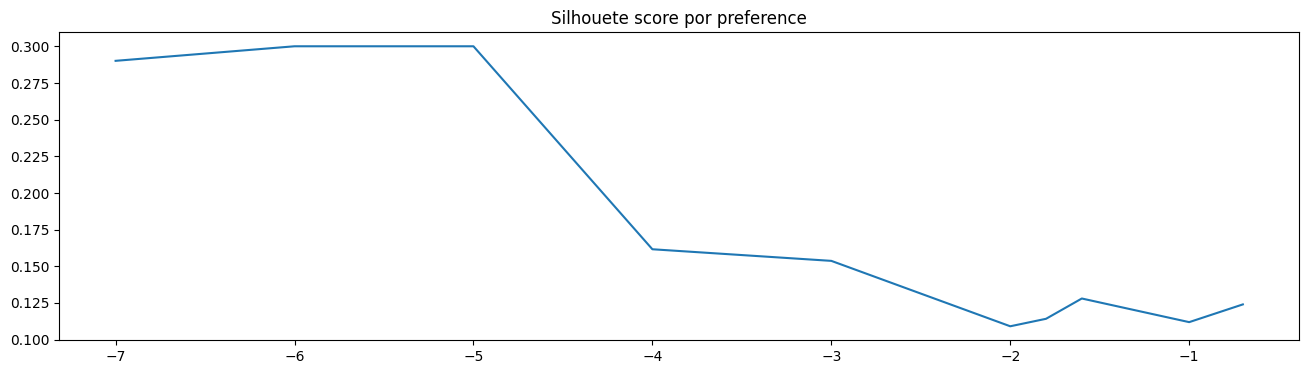

In [ ]:
preferences = [-7,-6,-5,-4,-3,-2,-1.8,-1.6,-1,-0.7]
n_clusters_ap  = []
ap_silhouete_score_values = []
ap_labels  = []

for preference in preferences:
    ap = AffinityPropagation(preference=preference) 
    ap.fit(dataset_normalized)
    n_clusters_ap.append(len(np.unique(ap.labels_)))
    ap_silhouete_score_values.append(mt.silhouette_score(dataset_normalized, ap.labels_))
    ap_labels.append(ap.labels_)

df_results_ap = pd.DataFrame(n_clusters_ap, columns = ['n_clusters'])
df_results_ap['preference']  = preferences
df_results_ap['silhouete']   = ap_silhouete_score_values
df_results_ap['predictions'] = ap_labels

df_results_ap_n_clusters    = df_results_ap.sort_values(by = 'n_clusters', ascending=True)
df_results_ap_preferences  = df_results_ap.sort_values(by = 'preference', ascending=True)

## 3.0 - Model Evaluation

### 3.2 - Affinity Propagation

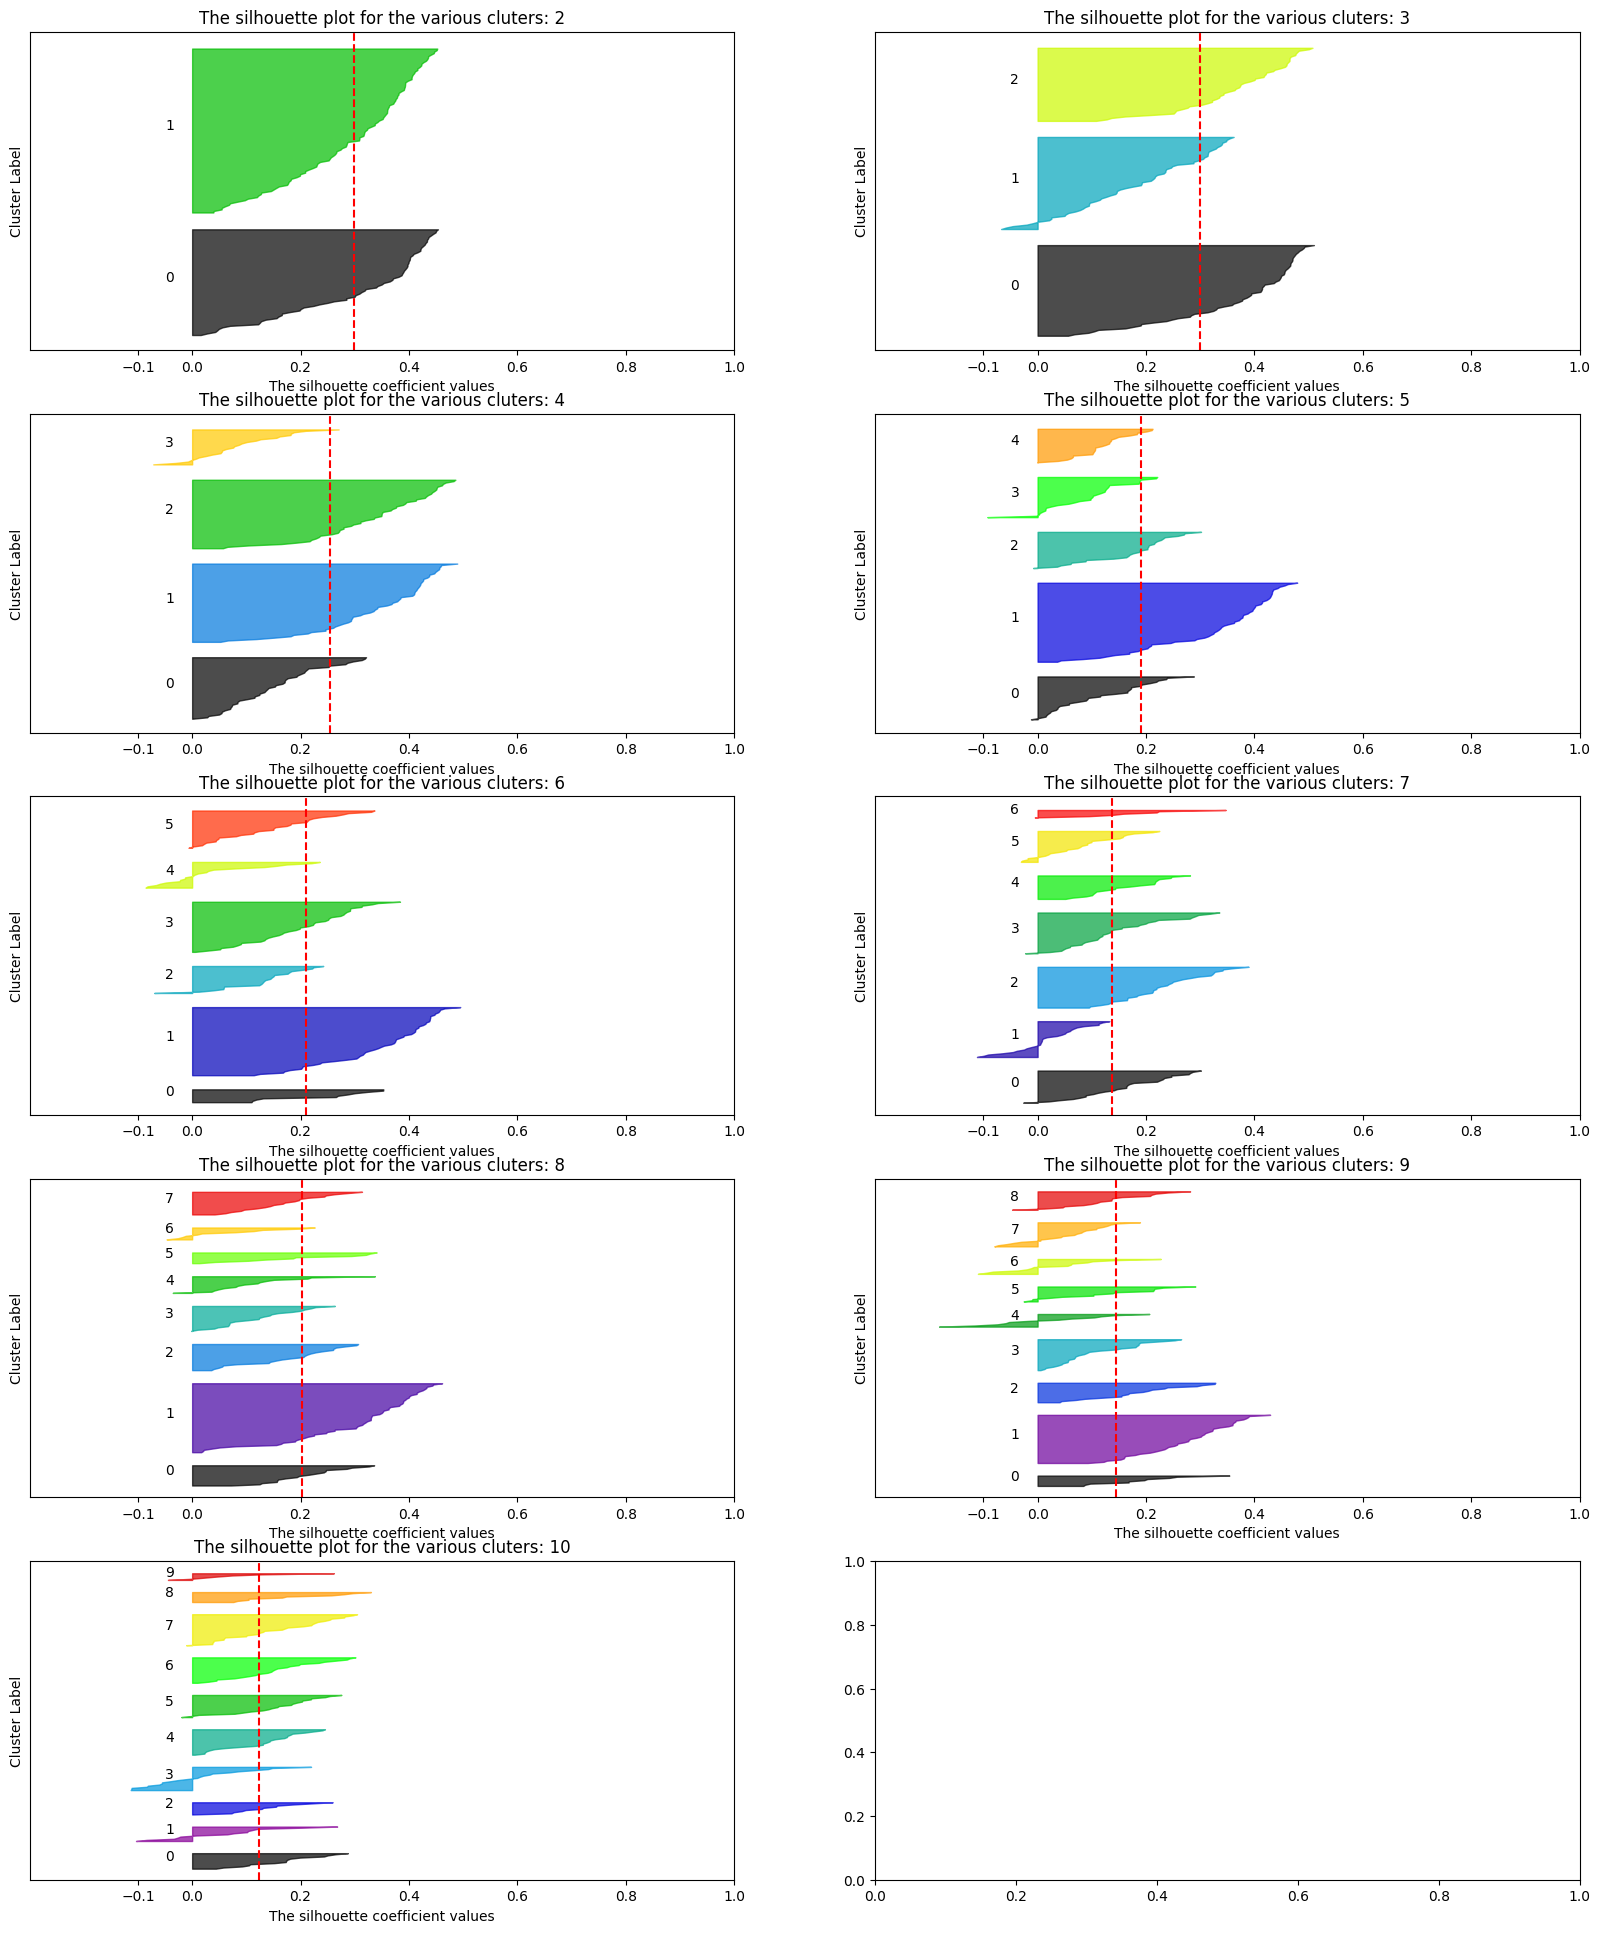

#### 3.2.1 - Fine Tunning

KMENAS

In [ ]:

plt.figure(figsize=(16,3))
plt.plot(k_values, kmeans_wcss_values)
plt.title('Inertia')

plt.figure(figsize=(16,3))
plt.plot(k_values, kmeans_silhouet_score_values)
plt.title('Silhouette')

df_kmeans = pd.DataFrame(k_values, columns=['n_clusters'])
df_kmeans['intertia'] = kmeans_wcss_values
df_kmeans['silhouete'] = kmeans_silhouet_score_values
df_kmeans['predictions'] = kmeans_predictions


AFFINITY PROPAGATION

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(df_results_ap_n_clusters['n_clusters'], df_results_ap_n_clusters['silhouete'])
plt.title('Silhouete score por n_clusters')

plt.figure(figsize=(16,4))
plt.plot(df_results_ap_preferences['preference'], 
         df_results_ap_preferences['silhouete'])

plt.title('Silhouete score por preference')




#### 3.2.2 - Análise individual dos clusters

KMEANS

In [ ]:

results_to_plot = df_kmeans[df_kmeans.n_clusters.isin([2,3,4,5,6,7,8,9,10])]
plot_knife_silhouete_values(n_clusters_values = results_to_plot['n_clusters'].values,
                            predictions  = results_to_plot['predictions'].values,
                            silhouette_scores = results_to_plot['silhouete'].values)

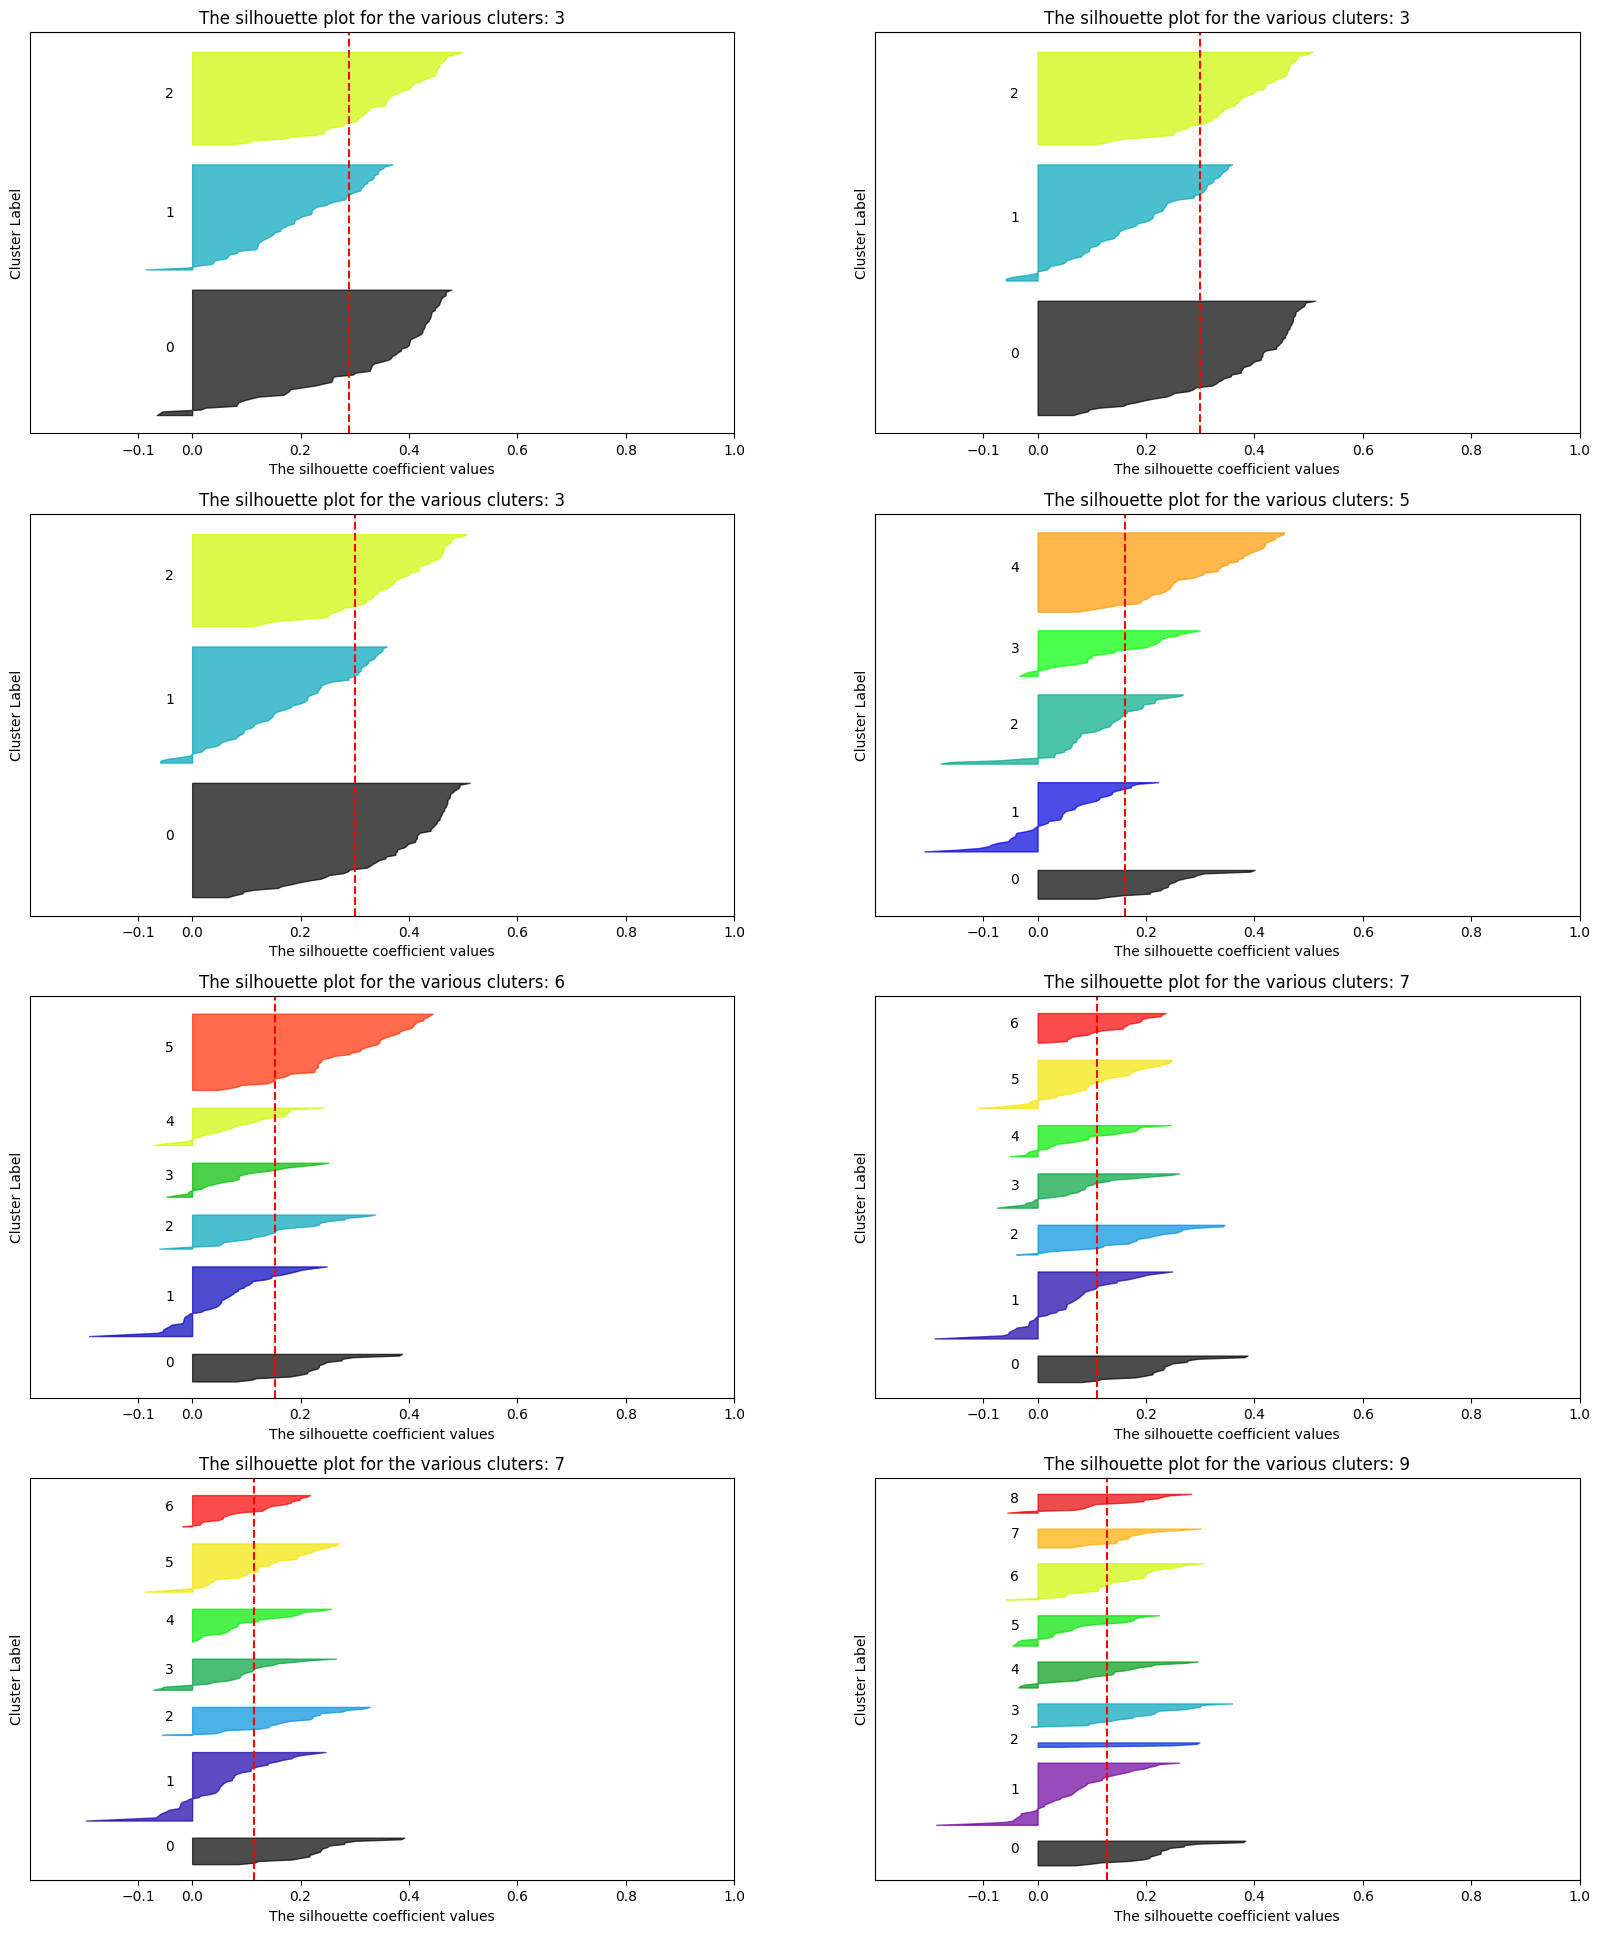

In [12]:

ap_results_to_plot = df_results_ap_preferences[df_results_ap_preferences.n_clusters.isin([2,3,4,5,6,7,8,9,10])]
plot_knife_silhouete_values(n_clusters_values   = ap_results_to_plot['n_clusters'].values,
                            predictions         = ap_results_to_plot['predictions'].values,
                            silhouette_scores   = ap_results_to_plot['silhouete'].values)

## 4.0 - Conclusões